In [1]:
%pip install matplotlib seaborn pandas numpy

  Using cached matplotlib-3.10.7-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.60.1-cp313-cp313-win_amd64.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-12.0.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached matplotlib-3.10.7-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached pandas-2.3.3-cp313-cp313-win_amd64.whl (11.0 MB)
   ----------------------------------------

In [3]:
"""
Step 1: Extract all data from log files
"""

import os
import re
import pandas as pd

CIRCUITS = ['cct1', 'cct2', 'cct3', 'cct4']
THREADS = [1, 2, 4, 8, 16, 32, 64, 128]

def extract_data_from_log(filepath):
    """Extract key metrics from a single log file"""
    if not os.path.exists(filepath):
        return None
    
    with open(filepath, 'r') as f:
        content = f.read()
    
    data = {}
    
    # Extract optimal cost
    match = re.search(r'Optimal cost:\s+(\d+)', content)
    if match:
        data['total_cost'] = int(match.group(1))
    
    # Extract crossing count
    match = re.search(r'Crossing count:\s+(\d+)', content)
    if match:
        data['crossing_cost'] = int(match.group(1))
    
    # Extract community cost
    match = re.search(r'Community cost:\s+(\d+)', content)
    if match:
        data['community_cost'] = int(match.group(1))
    
    # Extract nodes visited
    match = re.search(r'Nodes visited:\s+(\d+)', content)
    if match:
        data['nodes_visited'] = int(match.group(1))
    
    # Extract runtime in ms
    match = re.search(r'Runtime:\s+(\d+)\s+ms', content)
    if match:
        data['runtime_ms'] = int(match.group(1))
        data['runtime_s'] = int(match.group(1)) / 1000.0
    
    return data

# Load all data
print("Extracting data from log files...")
all_data = []

for cct in CIRCUITS:
    for t in THREADS:
        logfile = f'{cct}_log/{cct}_{t}t.txt'
        data = extract_data_from_log(logfile)
        
        if data:
            data['circuit'] = cct
            data['threads'] = t
            all_data.append(data)
            print(f"✓ {logfile}")
        else:
            print(f"✗ {logfile} - not found or parsing failed")

# Create DataFrame
df = pd.DataFrame(all_data)

print(f"\n{'='*60}")
print(f"Extracted {len(df)} results")
print(f"{'='*60}\n")

# Show sample
print("Sample data:")
print(df.head(10))

print("\n\nFull dataset:")
print(df.to_string())

# Save to CSV for easy access
df.to_csv('results.csv', index=False)
print("\n✓ Saved to results.csv")

Extracting data from log files...
✓ cct1_log/cct1_1t.txt
✓ cct1_log/cct1_2t.txt
✓ cct1_log/cct1_4t.txt
✓ cct1_log/cct1_8t.txt
✓ cct1_log/cct1_16t.txt
✓ cct1_log/cct1_32t.txt
✓ cct1_log/cct1_64t.txt
✓ cct1_log/cct1_128t.txt
✓ cct2_log/cct2_1t.txt
✓ cct2_log/cct2_2t.txt
✓ cct2_log/cct2_4t.txt
✓ cct2_log/cct2_8t.txt
✓ cct2_log/cct2_16t.txt
✓ cct2_log/cct2_32t.txt
✓ cct2_log/cct2_64t.txt
✓ cct2_log/cct2_128t.txt
✓ cct3_log/cct3_1t.txt
✓ cct3_log/cct3_2t.txt
✓ cct3_log/cct3_4t.txt
✓ cct3_log/cct3_8t.txt
✓ cct3_log/cct3_16t.txt
✓ cct3_log/cct3_32t.txt
✓ cct3_log/cct3_64t.txt
✓ cct3_log/cct3_128t.txt
✓ cct4_log/cct4_1t.txt
✓ cct4_log/cct4_2t.txt
✓ cct4_log/cct4_4t.txt
✓ cct4_log/cct4_8t.txt
✓ cct4_log/cct4_16t.txt
✓ cct4_log/cct4_32t.txt
✓ cct4_log/cct4_64t.txt
✓ cct4_log/cct4_128t.txt

Extracted 32 results

Sample data:
   total_cost  crossing_cost  community_cost  nodes_visited  runtime_ms  \
0          10             10               0             33           0   
1          10           

CCT1 Data:
   threads  nodes_visited
0        1             33
1        2             46
2        4             30
3        8             28
4       16             28
5       32             42
6       64             70
7      128            132

CCT2 Data:
    threads  nodes_visited
8         1          13639
9         2          24280
10        4          41280
11        8          37378
12       16          17128
13       32          21982
14       64          21698
15      128           9270

CCT3 Data:
    threads  nodes_visited
16        1          66203
17        2          49400
18        4          63716
19        8          80220
20       16          57414
21       32          42348
22       64          46408
23      128          43862

CCT4 Data:
    threads  nodes_visited
24        1       76773195
25        2       78006516
26        4       79094418
27        8       78815074
28       16       82087604
29       32       88890504
30       64       99322988
31      128      

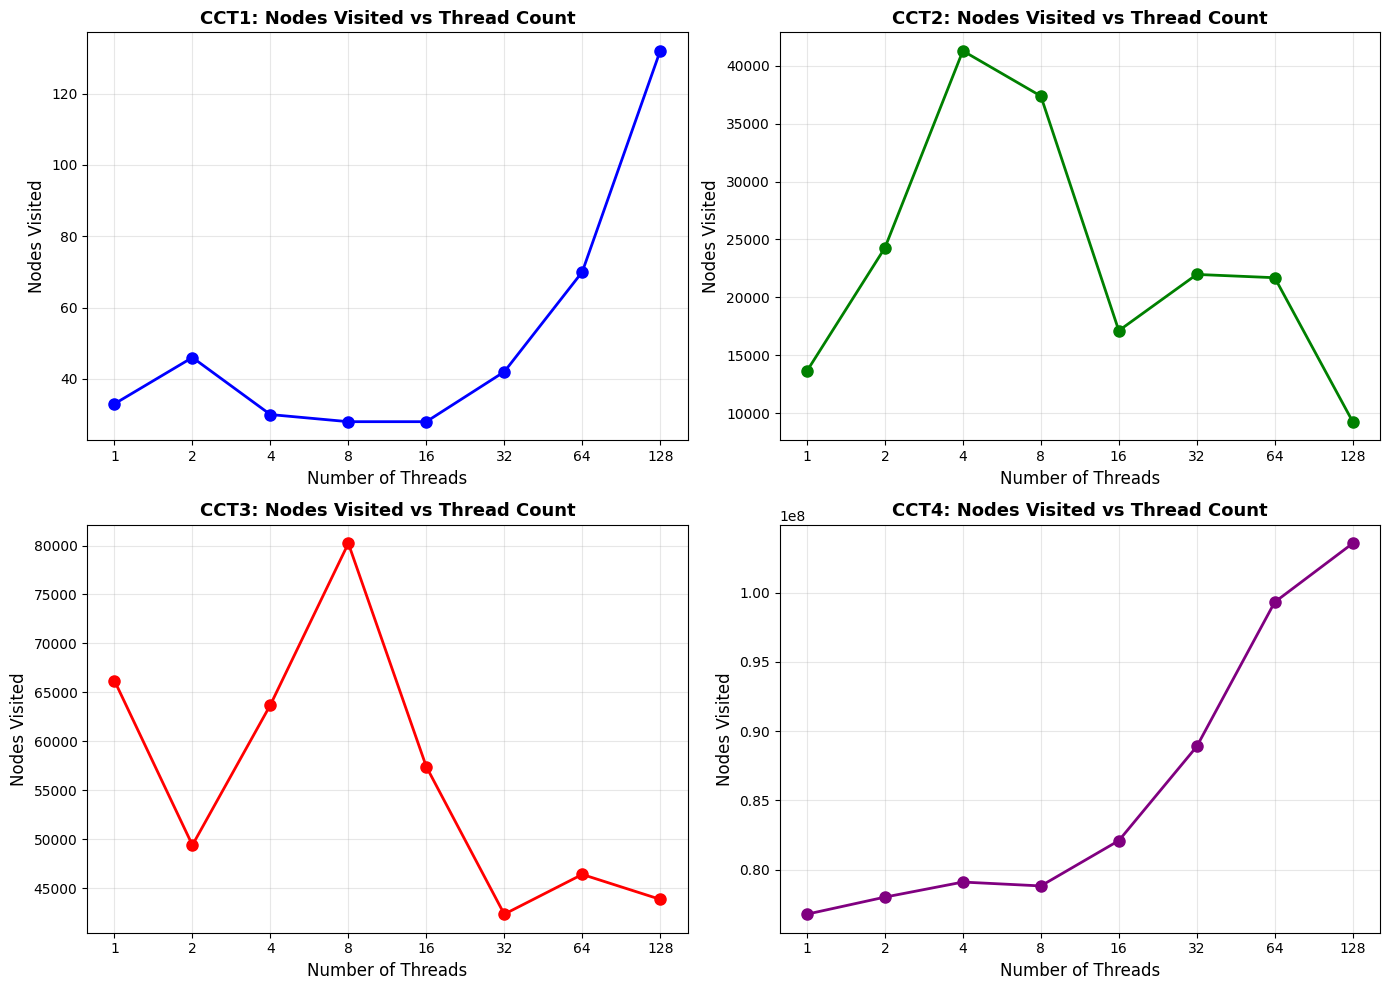


✓ Saved: all_circuits_nodes_vs_threads.png


In [5]:
"""
Step 2: Plot All Circuits - Nodes Visited vs Thread Count (2x2 grid)
"""

import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('results.csv')

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

circuits = ['cct1', 'cct2', 'cct3', 'cct4']
colors = ['blue', 'green', 'red', 'purple']

for idx, (cct, color) in enumerate(zip(circuits, colors)):
    cct_data = df[df['circuit'] == cct].sort_values('threads')
    
    print(f"{cct.upper()} Data:")
    print(cct_data[['threads', 'nodes_visited']])
    print()
    
    ax = axes[idx]
    ax.plot(cct_data['threads'], cct_data['nodes_visited'], 
            marker='o', linewidth=2, markersize=8, color=color)
    
    ax.set_xlabel('Number of Threads', fontsize=12)
    ax.set_ylabel('Nodes Visited', fontsize=12)
    ax.set_title(f'{cct.upper()}: Nodes Visited vs Thread Count', fontsize=13, fontweight='bold')
    ax.set_xscale('log', base=2)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(cct_data['threads'])
    ax.set_xticklabels(cct_data['threads'])

plt.tight_layout()
plt.savefig('all_circuits_nodes_vs_threads.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: all_circuits_nodes_vs_threads.png")

CCT1 Data:
   threads  runtime_s
0        1      0.000
1        2      0.001
2        4      0.002
3        8      0.002
4       16      0.002
5       32      0.005
6       64      0.003
7      128      0.008

CCT2 Data:
    threads  runtime_s
8         1      0.013
9         2      0.025
10        4      0.020
11        8      0.017
12       16      0.006
13       32      0.006
14       64      0.010
15      128      0.009

CCT3 Data:
    threads  runtime_s
16        1      0.099
17        2      0.060
18        4      0.048
19        8      0.041
20       16      0.029
21       32      0.023
22       64      0.020
23      128      0.018

CCT4 Data:
    threads  runtime_s
24        1    184.068
25        2    112.047
26        4     92.213
27        8     62.491
28       16     43.757
29       32     30.735
30       64     22.539
31      128     18.282



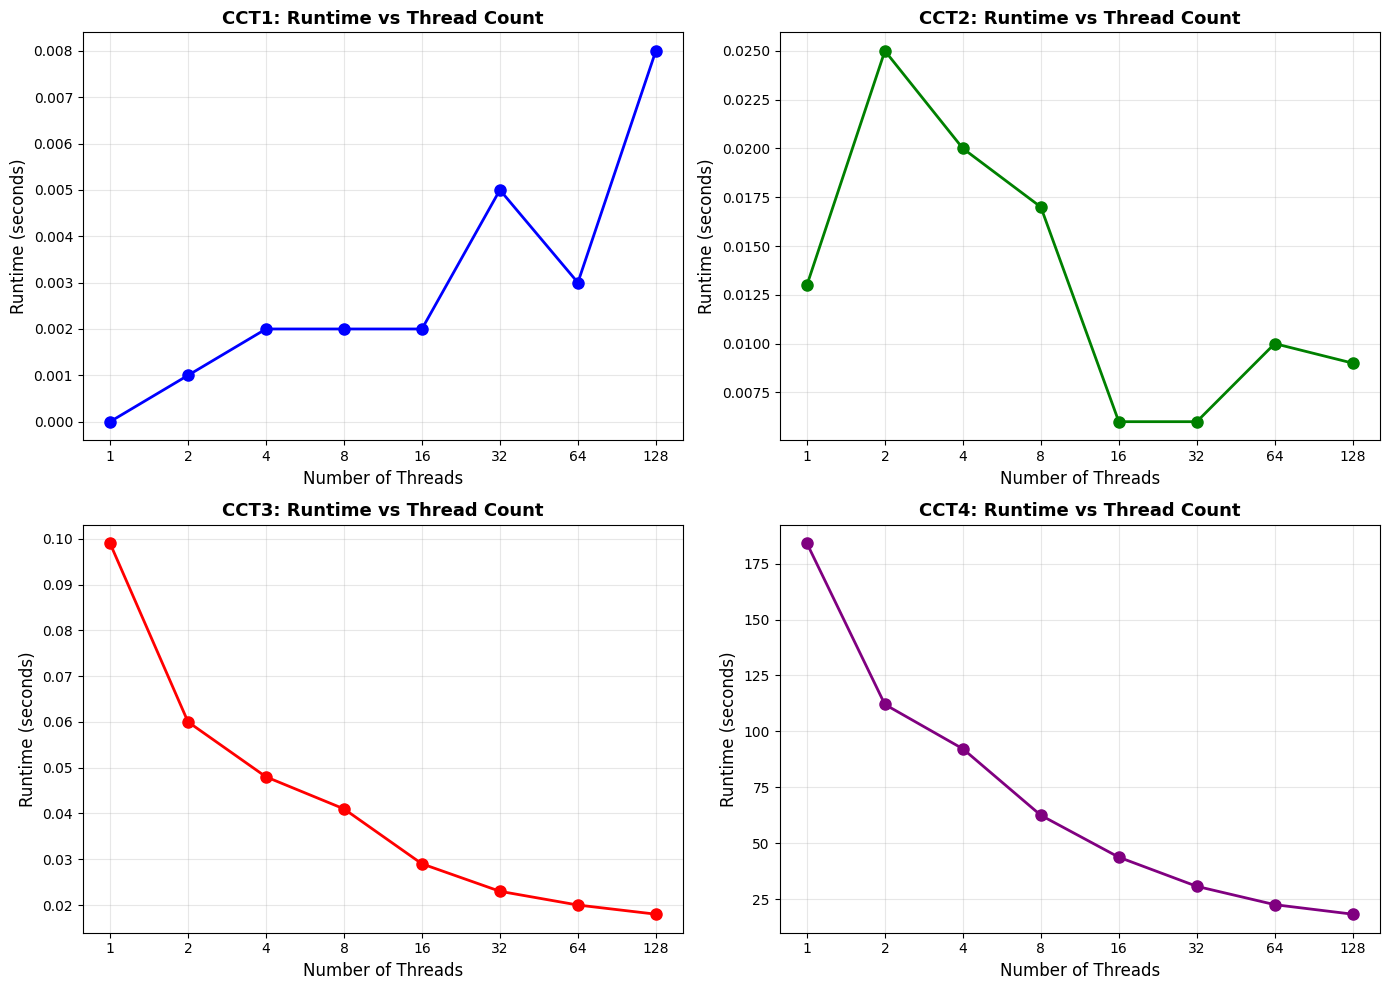


✓ Saved: all_circuits_runtime_vs_threads.png


In [7]:
"""
Step 3: Plot All Circuits - Runtime vs Thread Count (2x2 grid)
"""

import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('results.csv')

# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

circuits = ['cct1', 'cct2', 'cct3', 'cct4']
colors = ['blue', 'green', 'red', 'purple']

for idx, (cct, color) in enumerate(zip(circuits, colors)):
    cct_data = df[df['circuit'] == cct].sort_values('threads')
    
    print(f"{cct.upper()} Data:")
    print(cct_data[['threads', 'runtime_s']])
    print()
    
    ax = axes[idx]
    ax.plot(cct_data['threads'], cct_data['runtime_s'], 
            marker='o', linewidth=2, markersize=8, color=color)
    
    ax.set_xlabel('Number of Threads', fontsize=12)
    ax.set_ylabel('Runtime (seconds)', fontsize=12)
    ax.set_title(f'{cct.upper()}: Runtime vs Thread Count', fontsize=13, fontweight='bold')
    ax.set_xscale('log', base=2)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(cct_data['threads'])
    ax.set_xticklabels(cct_data['threads'])

plt.tight_layout()
plt.savefig('all_circuits_runtime_vs_threads.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: all_circuits_runtime_vs_threads.png")